In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [2]:
news_df = pd.read_csv("OnlineNewsPopularity.csv")

In [3]:
news_df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [4]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [5]:
#delete spaces in the column names
news_df.columns = news_df.columns.str.strip()

In [6]:
#analyzing target variable
news_df["shares"].describe()

count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64

In [7]:
#check if there are any missing values
total_missing = news_df.isnull().sum().sum()
total_missing

np.int64(0)

In [8]:
#check if there are any duplicated rows
n_dup_rows = news_df.duplicated().sum()
n_dup_rows

np.int64(0)

In [9]:
q95 = news_df["shares"].quantile(0.95)
q95

np.float64(10800.0)

In [10]:
q99 = news_df["shares"].quantile(0.99)
q99

np.float64(31656.99999999997)

In [11]:
news_df.corr(numeric_only=True)["shares"].sort_values(ascending=False)

shares                           1.000000
kw_avg_avg                       0.110413
LDA_03                           0.083771
kw_max_avg                       0.064306
self_reference_avg_sharess       0.057789
self_reference_min_shares        0.055958
self_reference_max_shares        0.047115
num_hrefs                        0.045404
kw_avg_max                       0.044686
kw_min_avg                       0.039551
num_imgs                         0.039388
global_subjectivity              0.031604
kw_avg_min                       0.030406
kw_max_min                       0.030114
abs_title_sentiment_polarity     0.027135
num_videos                       0.023936
title_subjectivity               0.021967
num_keywords                     0.021818
is_weekend                       0.016958
weekday_is_saturday              0.015082
title_sentiment_polarity         0.012772
avg_positive_polarity            0.012142
max_positive_polarity            0.010068
weekday_is_monday                0

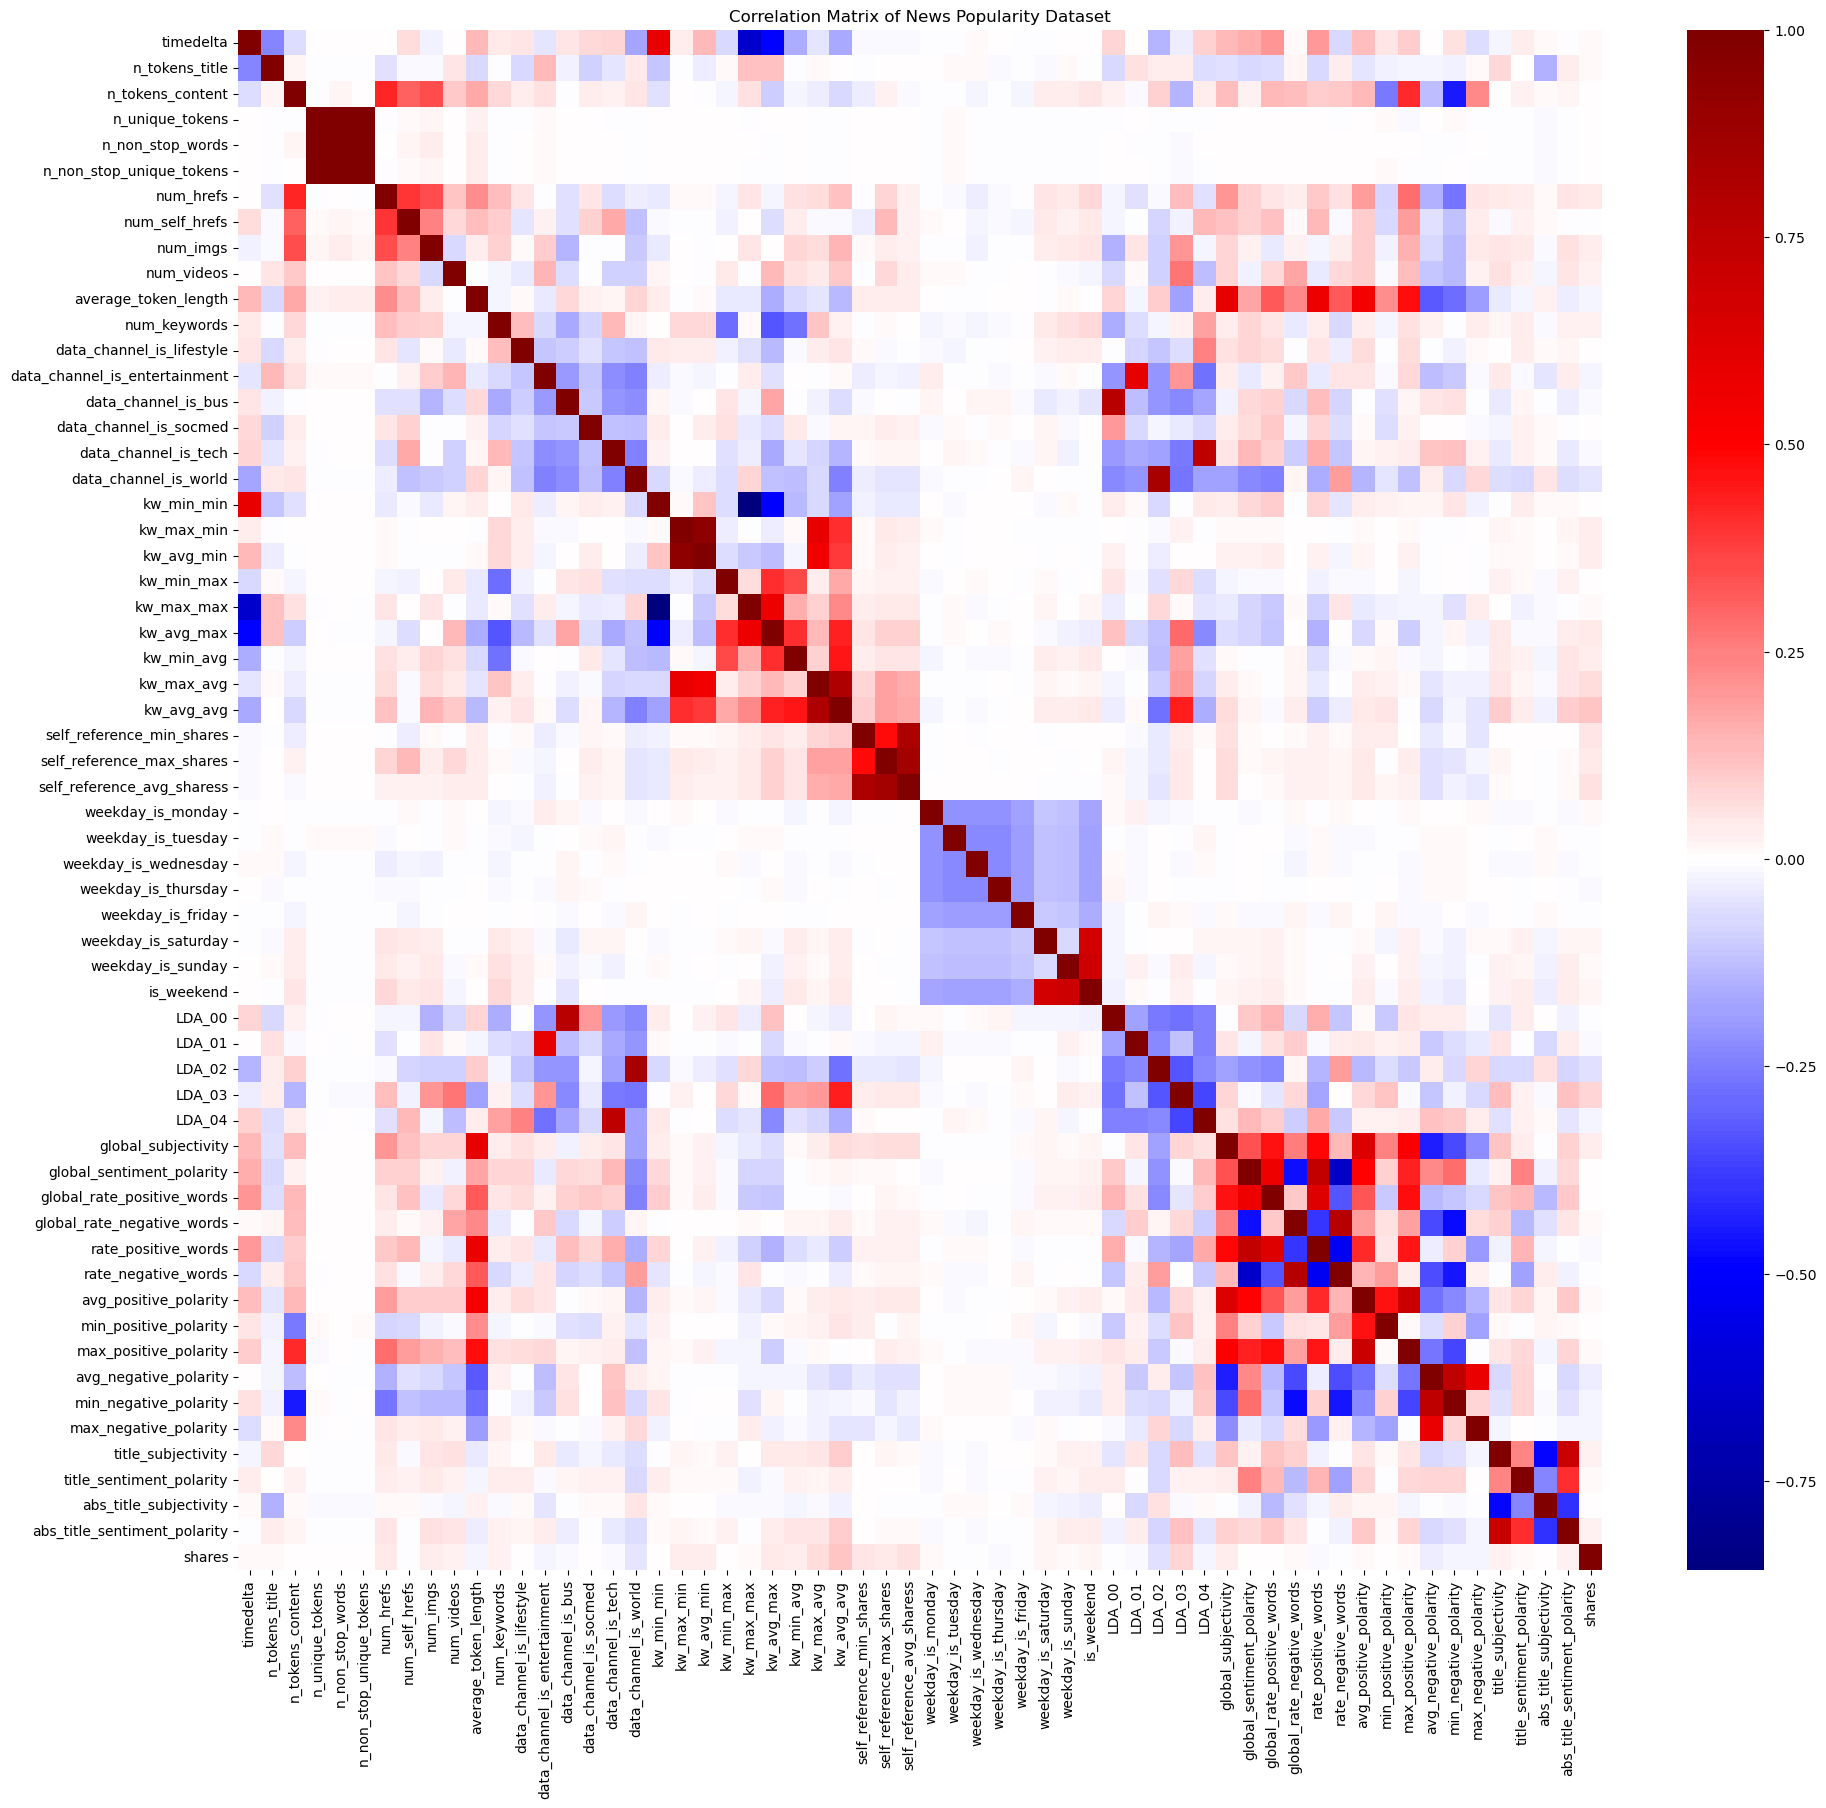

In [12]:
plt.figure(figsize=(22, 20))
corr_matrix = news_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="seismic", center=0)
plt.title("Correlation Matrix of News Popularity Dataset")
plt.show()

In [13]:
#popularity threshold and a new variable 'popular'
median_shares = news_df["shares"].median()
news_df["popular"] = (news_df["shares"] > median_shares).astype(int)

In [14]:
#define virality_score
news_df["keyword_density"] = news_df["num_keywords"] / news_df["n_tokens_content"]
news_df["keyword_density"] = news_df["keyword_density"].replace([np.inf, -np.inf], np.nan)
news_df["keyword_density"] = news_df["keyword_density"].fillna(0)

news_df["virality_score"] = (
    0.4 * np.log1p(news_df["num_hrefs"]) +
    0.3 * np.log1p(news_df["num_self_hrefs"]) +
    0.2 * news_df["keyword_density"] -
    0.1 * np.log1p(news_df["timedelta"])
)

news_df["virality_score"] = news_df["virality_score"].replace([np.inf, -np.inf], np.nan)
news_df["virality_score"] = news_df["virality_score"].fillna(news_df["virality_score"].median())

In [15]:
news_df[["virality_score", "shares"]].corr()

,virality_score,shares
virality_score,1.000000,0.016474
shares,0.016474,1.000000


In [16]:
#define topic_specialization
channel_cols = [
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    "data_channel_is_world"
]

# avg shares for each channel
channel_popularity = {
    col: news_df.loc[news_df[col] == 1, "shares"].mean()
    for col in channel_cols
}
channel_popularity

{'data_channel_is_lifestyle': np.float64(3682.123392091472),
 'data_channel_is_entertainment': np.float64(2970.487034150489),
 'data_channel_is_bus': np.float64(3063.0185362735697),
 'data_channel_is_socmed': np.float64(3629.383125269049),
 'data_channel_is_tech': np.float64(3072.283283419548),
 'data_channel_is_world': np.float64(2287.734069063724)}

In [17]:
channel_popularity_series = pd.Series(channel_popularity)

news_df["topic_specialization"] = news_df[channel_cols].dot(channel_popularity_series)

In [18]:
news_df[["topic_specialization", "shares"]].corr()

,topic_specialization,shares
topic_specialization,1.000000,-0.076348
shares,-0.076348,1.000000


In [19]:
#define text_complexity
denom = news_df["n_tokens_content"].replace(0, np.nan)

ratio_non_stop = news_df["n_non_stop_words"] / denom
ratio_non_stop_unique = news_df["n_non_stop_unique_tokens"] / denom

ratio_non_stop = ratio_non_stop.replace([np.inf, -np.inf], np.nan).fillna(0)
ratio_non_stop_unique = ratio_non_stop_unique.replace([np.inf, -np.inf], np.nan).fillna(0)

news_df["text_complexity"] = (
    0.5 * news_df["average_token_length"] +
    0.3 * ratio_non_stop +
    0.2 * ratio_non_stop_unique
)

news_df["text_complexity"] = (
    news_df["text_complexity"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(news_df["text_complexity"].median())
)

In [20]:
news_df[["text_complexity", "shares"]].corr()

,text_complexity,shares
text_complexity,1.00000,-0.02197
shares,-0.02197,1.00000


In [21]:
#define sentiment_power
news_df["sentiment_power"] = (
    abs(news_df["global_sentiment_polarity"]) *
    (news_df["rate_positive_words"] + news_df["rate_negative_words"])
)

In [22]:
news_df[["sentiment_power", "shares"]].corr()

,sentiment_power,shares
sentiment_power,1.000000,0.011323
shares,0.011323,1.000000


In [23]:
#define seo_strength
ratio_unique = news_df["n_unique_tokens"] / news_df["n_tokens_content"].replace(0, np.nan)
ratio_unique = ratio_unique.replace([np.inf, -np.inf], np.nan)
ratio_unique = ratio_unique.fillna(0)

news_df["seo_strength"] = (
    0.4 * np.log1p(news_df["num_keywords"].clip(lower=0)) +
    0.3 * ratio_unique +
    0.3 * news_df["n_tokens_title"]
)

news_df["seo_strength"] = news_df["seo_strength"].replace([np.inf, -np.inf], np.nan)
news_df["seo_strength"] = news_df["seo_strength"].fillna(news_df["seo_strength"].median())

In [24]:
news_df[["seo_strength", "shares"]].corr()

,seo_strength,shares
seo_strength,1.000000,0.012425
shares,0.012425,1.000000


In [25]:
new_features = [
    "virality_score",
    "topic_specialization",
    "text_complexity",
    "sentiment_power",
    "seo_strength"
]


param_grid = {
    "n_estimators": [150, 300],
    "max_depth": [None, 5, 15],
    "max_features": ["sqrt", 0.5]
}


def evaluate_single_feature(feature):
    print(f" Evaluating feature: {feature}")

    X = news_df[[feature]]
    y = news_df["popular"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(random_state=42)

    # GridSearchCV
    grid = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\nBest parameters:", grid.best_params_)
    print("Best CV accuracy:", round(grid.best_score_, 3))

    # Test performance
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    test_acc = accuracy_score(y_test, y_pred)
    print("Test accuracy:", round(test_acc, 3))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=3))


for feat in new_features:
    evaluate_single_feature(feat)

 Evaluating feature: virality_score

Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 150}
Best CV accuracy: 0.54
Test accuracy: 0.54

Classification report:
              precision    recall  f1-score   support

           0      0.533     0.730     0.616      4017
           1      0.554     0.344     0.424      3912

    accuracy                          0.540      7929
   macro avg      0.543     0.537     0.520      7929
weighted avg      0.543     0.540     0.522      7929

 Evaluating feature: topic_specialization

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 150}
Best CV accuracy: 0.609
Test accuracy: 0.603

Classification report:
              precision    recall  f1-score   support

           0      0.600     0.650     0.624      4017
           1      0.607     0.555     0.580      3912

    accuracy                          0.603      7929
   macro avg      0.604     0.603     0.602      7929
weighted avg      0.604 

In [26]:
drop_cols = ["shares", "popular"] 
feature_cols = [col for col in news_df.select_dtypes(include=[np.number]).columns
                if col not in drop_cols]

X = news_df[feature_cols]
y = news_df["popular"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "LogReg_Std": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            solver="lbfgs"
        ))
    ]),
    "RandomForest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )
}

param_grids = {
    "LogReg_Std": {
        "clf__C": [0.1, 1.0, 3.0],
        "clf__penalty": ["l2"]
    },
    "RandomForest": {
        "n_estimators": [150, 300],
        "max_depth": [None, 10, 20],
        "max_features": ["sqrt", 0.5]
    }
}

In [27]:
results = []

for name, model in models.items():
    print(f"Model: {name}")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_trainval, y_trainval)

    best_model = grid.best_estimator_
    val_acc = grid.best_score_

    y_pred = best_model.predict(X_test)
    
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    test_acc = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred)
    test_rec = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    
    if y_proba is not None:
        test_roc = roc_auc_score(y_test, y_proba)
    else:
        test_roc = np.nan

    print("Best params:", grid.best_params_)
    print("Validation accuracy (CV):", round(val_acc, 3))
    print("Test accuracy:", round(test_acc, 3))
    print("Test F1:", round(test_f1, 3))
    print("Test ROC-AUC:", round(test_roc, 3))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=3))

    results.append({
        "Model": name,
        "Best_params": grid.best_params_,
        "Val_Accuracy": round(val_acc, 3),
        "Test_Accuracy": round(test_acc, 3),
        "Test_Precision": round(test_prec, 3),
        "Test_Recall": round(test_rec, 3),
        "Test_F1": round(test_f1, 3),
        "Test_ROC_AUC": round(test_roc, 3)
    })

results_df = pd.DataFrame(results)
results_df

Model: LogReg_Std
Best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
Validation accuracy (CV): 0.651
Test accuracy: 0.653
Test F1: 0.642
Test ROC-AUC: 0.701

Classification report:
              precision    recall  f1-score   support

           0      0.652     0.675     0.663      4017
           1      0.654     0.630     0.642      3912

    accuracy                          0.653      7929
   macro avg      0.653     0.653     0.652      7929
weighted avg      0.653     0.653     0.653      7929

Model: RandomForest
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300}
Validation accuracy (CV): 0.667
Test accuracy: 0.666
Test F1: 0.664
Test ROC-AUC: 0.727

Classification report:
              precision    recall  f1-score   support

           0      0.673     0.664     0.668      4017
           1      0.660     0.668     0.664      3912

    accuracy                          0.666      7929
   macro avg      0.666     0.666     0.666      7929
weighted avg

,Model,Best_params,Val_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,LogReg_Std,"{'clf__C': 0.1, 'clf__penalty': 'l2'}",0.651,0.653,0.654,0.630,0.642,0.701
1,RandomForest,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.667,0.666,0.660,0.668,0.664,0.727


kw_avg_avg                    0.041886
kw_max_avg                    0.037237
self_reference_min_shares     0.029732
LDA_02                        0.029635
timedelta                     0.027296
self_reference_avg_sharess    0.025350
LDA_01                        0.025123
LDA_04                        0.024825
kw_avg_max                    0.024783
LDA_00                        0.024650
kw_avg_min                    0.024433
virality_score                0.024027
global_subjectivity           0.022857
n_unique_tokens               0.022807
n_non_stop_unique_tokens      0.022724
LDA_03                        0.022723
seo_strength                  0.022415
kw_max_min                    0.021982
global_rate_positive_words    0.021717
keyword_density               0.021296
dtype: float64


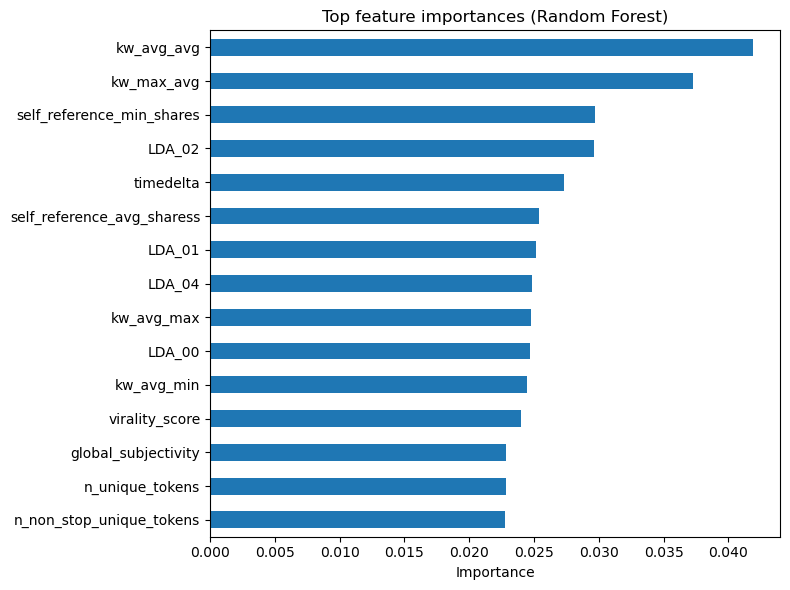

In [28]:
best_rf_params = results_df.loc[results_df["Model"] == "RandomForest", "Best_params"].iloc[0]
best_rf = RandomForestClassifier(random_state=42, n_jobs=-1, **best_rf_params)
best_rf.fit(X_trainval, y_trainval)

importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print(importances.head(20))

import matplotlib.pyplot as plt

top_n = 15
plt.figure(figsize=(8, 6))
importances.head(top_n).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top feature importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [29]:
lda_cols = [c for c in news_df.columns if c.startswith("LDA_")]

base_candidates = [
    "n_non_stop_words",
    "n_non_stop_unique_tokens",
    "n_unique_tokens",
    "average_token_length",

    "global_sentiment_polarity",
    "global_subjectivity",
    "global_rate_positive_words",
    "global_rate_negative_words",

    "text_complexity",
    "sentiment_power",
    "topic_specialization",
]

cluster_features = lda_cols + [c for c in base_candidates if c in news_df.columns]

print("Features used for clustering:", cluster_features)

Features used for clustering: ['LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'n_unique_tokens', 'average_token_length', 'global_sentiment_polarity', 'global_subjectivity', 'global_rate_positive_words', 'global_rate_negative_words', 'text_complexity', 'sentiment_power', 'topic_specialization']


In [30]:
X = news_df[cluster_features].copy()

X = X.replace([np.inf, -np.inf], np.nan)


prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = prep.fit_transform(X)

In [39]:
k = 3

cluster_model = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward"
)

news_df["cluster"] = cluster_model.fit_predict(X_scaled)

print(news_df["cluster"].value_counts())

cluster
0    38462
2     1181
1        1
Name: count, dtype: int64


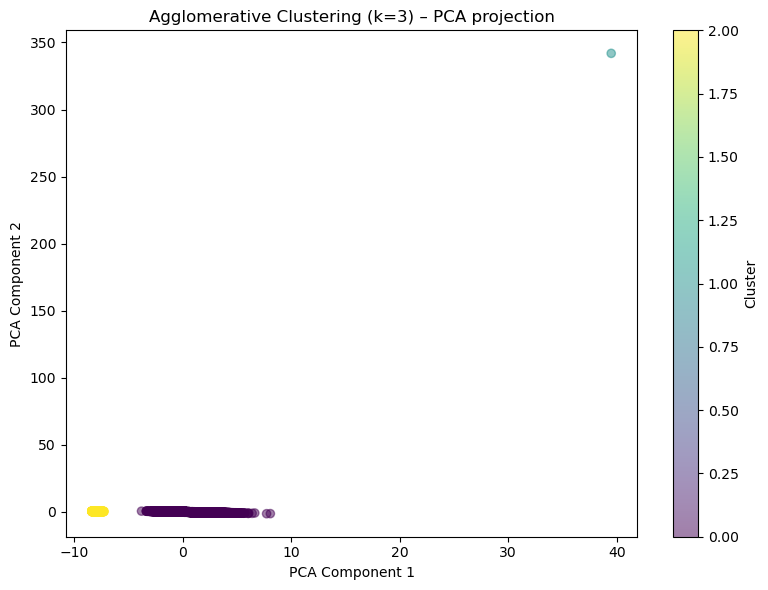

In [40]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=news_df["cluster"],
    alpha=0.5
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Agglomerative Clustering (k=3) – PCA projection")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

In [42]:
cluster_profile = news_df.groupby("cluster")[
    [
        "topic_specialization",
        "sentiment_power",
        "text_complexity",
        "seo_strength",
        "virality_score"
    ]
].mean()

cluster_profile

,topic_specialization,sentiment_power,text_complexity,seo_strength,virality_score
cluster,,,,,
0,2513.820675,0.13225,2.345295,3.945685,0.705693
1,2970.487034,0.00000,2.630000,3.665726,1.217938
2,1227.025999,0.00000,0.000000,4.127784,-0.466366
